In [67]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader


In [68]:
train_dir = r"D:\Medical_AI_System\data\mri\train"
test_dir = r"D:\Medical_AI_System\data\mri\test"

transform = transforms.Compose([
    transforms.Grayscale(),
    transforms.Resize((128,128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(5),
    transforms.ToTensor()
])

In [69]:
train_dataset = datasets.ImageFolder(root = train_dir,transform = transform) # calling the above defined preprocessing step
test_dataset = datasets.ImageFolder(root = test_dir,transform = transform)

train_loader = DataLoader(train_dataset, batch_size = 32, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size = 32, shuffle = False)

print("Classes:", train_dataset.classes)


Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [70]:
print("Train Size:", len(train_dataset))
print("Test Size:", len(test_dataset))

Train Size: 5600
Test Size: 1600


In [71]:
img, label = train_dataset[0]
print(label)
print(img)
print(type(img))
print(img.shape)

0
tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]])
<class 'torch.Tensor'>
torch.Size([1, 128, 128])


In [72]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [73]:
class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__() # super calls the parent class --> nn.Module
        self.conv1 = nn.Conv2d(1,16,3)
        self.conv2 = nn.Conv2d(16,32,3)
        self.pool = nn.MaxPool2d(2,2)
        self.dropout = nn.Dropout(0.5)
        self.fc1 = nn.Linear(32*30*30,128)
        self.fc2 = nn.Linear(128, 4)
    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x


In [74]:
model = CNNModel()
print(model)

CNNModel(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=28800, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=4, bias=True)
)


In [75]:
criterion = nn.CrossEntropyLoss() # Adding Loss Function

In [76]:
import torch.optim as optim

optimizer = optim.Adamax(model.parameters(), lr = 0.001)


In [77]:
epochs = 30

for epoch in range(epochs):
    running_loss = 0.0
    for images, labels in train_loader:
        optimizer.zero_grad()
        output = model(images)
        loss = criterion(output, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"epoch{epoch+1}, Loss: {running_loss:.4f}")

epoch1, Loss: 145.6460
epoch2, Loss: 101.5039
epoch3, Loss: 91.1688
epoch4, Loss: 81.0825
epoch5, Loss: 75.6692
epoch6, Loss: 69.7131
epoch7, Loss: 67.1720
epoch8, Loss: 61.2953
epoch9, Loss: 59.0464
epoch10, Loss: 55.0972
epoch11, Loss: 50.8729
epoch12, Loss: 48.5055
epoch13, Loss: 46.3126
epoch14, Loss: 43.4916
epoch15, Loss: 41.2202
epoch16, Loss: 39.7280
epoch17, Loss: 38.0627
epoch18, Loss: 35.0720
epoch19, Loss: 35.0674
epoch20, Loss: 33.4060
epoch21, Loss: 31.6147
epoch22, Loss: 29.1593
epoch23, Loss: 28.9292
epoch24, Loss: 26.0782
epoch25, Loss: 26.1951
epoch26, Loss: 24.6078
epoch27, Loss: 24.7715
epoch28, Loss: 24.5965
epoch29, Loss: 20.9262
epoch30, Loss: 22.9339


In [78]:
correct = 0
total = 0
with torch.no_grad():
    for images,labels in test_loader:
        outputs = model(images)

        _, predicted = torch.max(outputs,1)

        total +=labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100*correct/total

print(f"Accuracy: {accuracy:.2f}%")


Accuracy: 86.81%


In [100]:
y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        
        y_true.extend(labels.numpy())
        y_pred.extend(predicted.numpy())

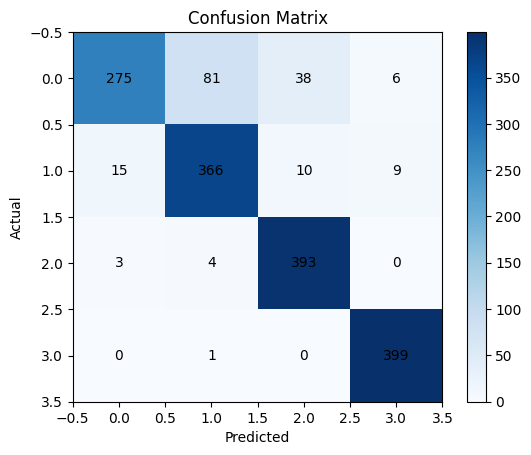

In [117]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure()
plt.imshow(cm, cmap = 'Blues')
plt.title("Confusion Matrix")
plt.colorbar()

plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(len(cm)):
    for j in range(len(cm)):
        plt.text(j, i, cm[i][j], ha='center', va='center')

plt.show()

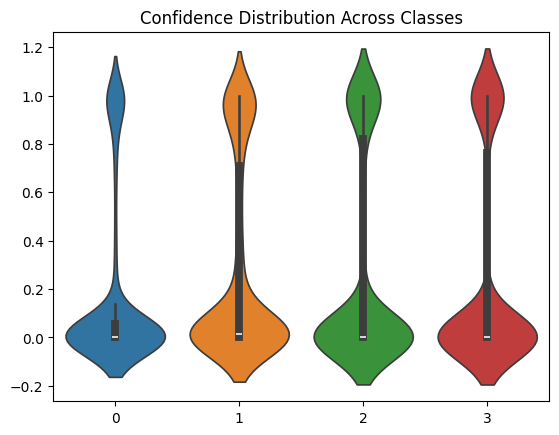

In [105]:
import seaborn as sns
import numpy as np

all_probs = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        
        all_probs.extend(probs.numpy())
        all_labels.extend(labels.numpy())

all_probs = np.array(all_probs)

plt.figure()
sns.violinplot(data=all_probs)
plt.title("Confidence Distribution Across Classes")
plt.show()

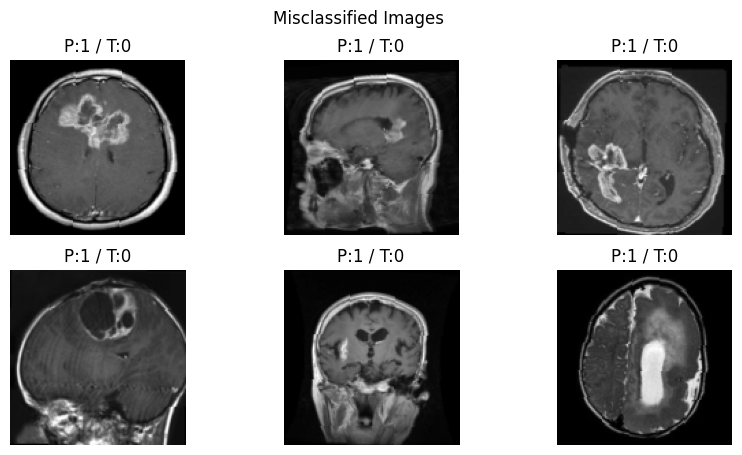

In [106]:
mis_images = []
mis_preds = []
mis_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        
        for i in range(len(images)):
            if preds[i] != labels[i]:
                mis_images.append(images[i])
                mis_preds.append(preds[i].item())
                mis_labels.append(labels[i].item())

# show first 6 mistakes
plt.figure(figsize=(10,5))
for i in range(min(6, len(mis_images))):
    plt.subplot(2,3,i+1)
    plt.imshow(mis_images[i].squeeze(), cmap='gray')
    plt.title(f"P:{mis_preds[i]} / T:{mis_labels[i]}")
    plt.axis('off')

plt.suptitle("Misclassified Images")
plt.show()

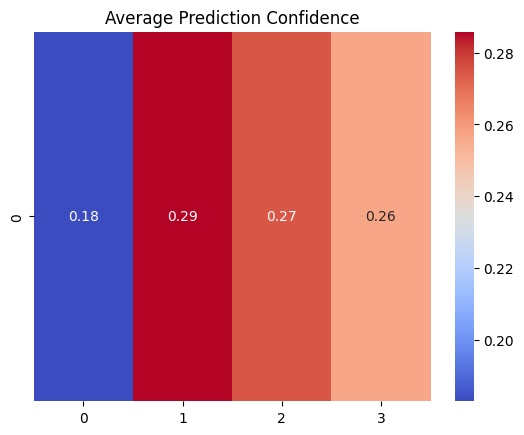

In [107]:
avg_probs = all_probs.mean(axis=0)

plt.figure()
sns.heatmap([avg_probs], annot=True, cmap="coolwarm")
plt.title("Average Prediction Confidence")
plt.show()

In [79]:
torch.save(model.state_dict(),r"D:\Medical_AI_System\models\mri_model_v2.pth")

In [80]:
from PIL import Image
import matplotlib.pyplot as plt


In [81]:
img_path = r"D:\Medical_AI_System\data\mri\test\glioma\Te-gl_5.jpg"

(-0.5, 511.5, 511.5, -0.5)

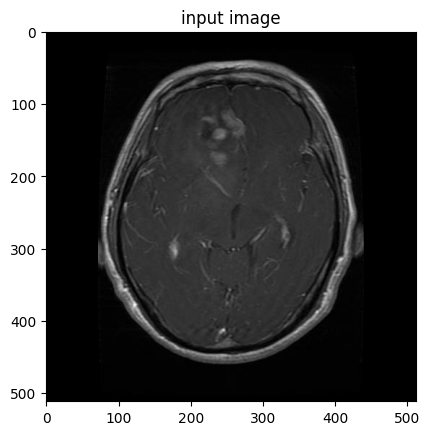

In [82]:
image = Image.open(img_path)


plt.imshow(image)
plt.title("input image")
plt.axis('on')

In [83]:
image = transform(image)
image = image.unsqueeze(0)

In [119]:
model = CNNModel()
model.load_state_dict(torch.load(r"D:\Medical_AI_System\models\mri_model_v2.pth"))
model.eval()

C:\Users\jeffr\AppData\Local\Temp\ipykernel_29236\4076973273.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(r"D:\Medical_AI_System\mode

CNNModel(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=28800, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=4, bias=True)
)

In [120]:
with torch.no_grad():
    output = model(image)
    _, predicted = torch.max(output,1)

print("predicted_class: ", predicted.item())

predicted_class:  1


In [121]:
classes = ['glioma', 'meningioma', 'no_tumor', 'pituitary']
print("Prediction:", classes[predicted.item()])

Prediction: meningioma


In [122]:
import pandas as pd
from sklearn.model_selection import train_test_split

In [123]:
df = pd.read_csv(r"D:\Medical_AI_System\data\heart.csv")

print(df.head())
print(df.shape)

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  
(1025, 14)


In [124]:
X = df.drop('target', axis = 1)
y = df["target"]

print(X.shape)
print(y.shape)

(1025, 13)
(1025,)


In [125]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2, random_state=42
)

print(X_train.shape)
print(X_test.shape)

(820, 13)
(205, 13)


In [126]:
from sklearn.ensemble import RandomForestClassifier

model_tab = RandomForestClassifier()
model_tab.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [127]:
import pickle

pickle.dump(model_tab, open(r"D:\Medical_AI_System\models\tabular_model_v2.pkl", "wb"))

In [128]:
from sklearn.metrics import accuracy_score

y_pred = model_tab.predict(X_test)

accuracy = accuracy_score(y_test,y_pred)

print(f"Tabular Model Accuracy: {accuracy*100:.2f}%")

Tabular Model Accuracy: 98.54%


In [129]:
print(y.value_counts())

target
1    526
0    499
Name: count, dtype: int64


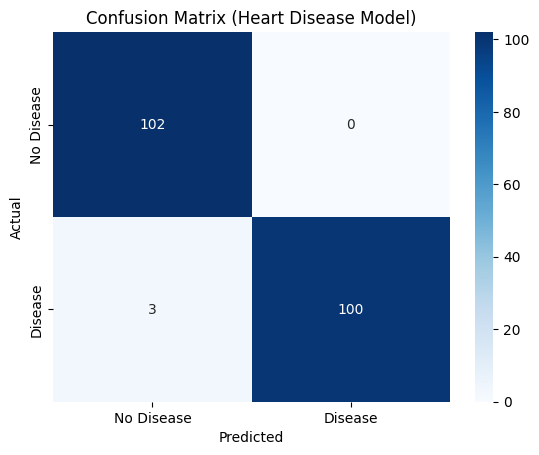

In [132]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["No Disease", "Disease"],
            yticklabels=["No Disease", "Disease"])

plt.title("Confusion Matrix (Heart Disease Model)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

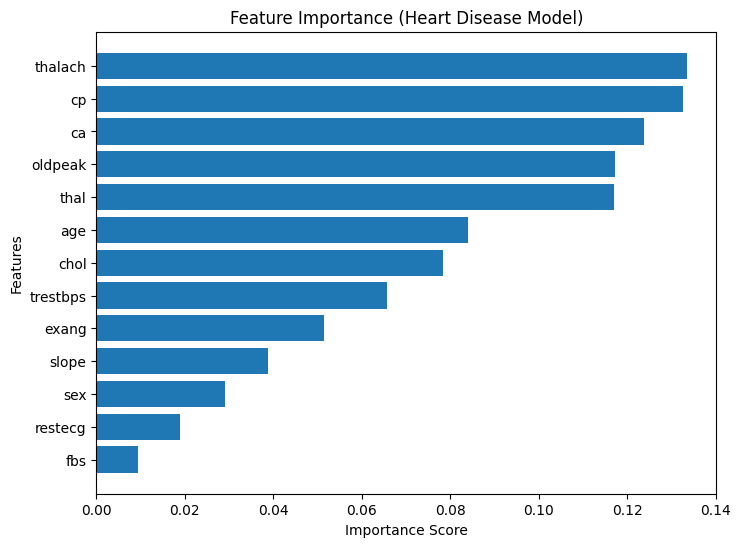

In [110]:
import pandas as pd
import matplotlib.pyplot as plt

importance = model_tab.feature_importances_

features = X.columns

# sort for better visualization
sorted_idx = importance.argsort()

plt.figure(figsize=(8,6))
plt.barh(features[sorted_idx], importance[sorted_idx])
plt.title("Feature Importance (Heart Disease Model)")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

In [113]:
import cv2
import numpy as np

def generate_gradcam(model, image, target_layer):
    gradients = []
    activations = []

    def backward_hook(module, grad_in, grad_out):
        gradients.append(grad_out[0])

    def forward_hook(module, inp, out):
        activations.append(out)

    # register hooks
    handle_f = target_layer.register_forward_hook(forward_hook)
    handle_b = target_layer.register_backward_hook(backward_hook)

    output = model(image)
    pred_class = output.argmax(dim=1)

    model.zero_grad()
    output[0, pred_class].backward()

    grads = gradients[0]
    acts = activations[0]

    weights = grads.mean(dim=(2,3), keepdim=True)
    cam = (weights * acts).sum(dim=1)

    cam = cam.squeeze().detach().numpy()
    cam = np.maximum(cam, 0)
    cam = cam / cam.max()

    # resize to image size
    cam = cv2.resize(cam, (128,128))

    handle_f.remove()
    handle_b.remove()

    return cam

c:\Users\jeffr\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\nn\modules\module.py:1827: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


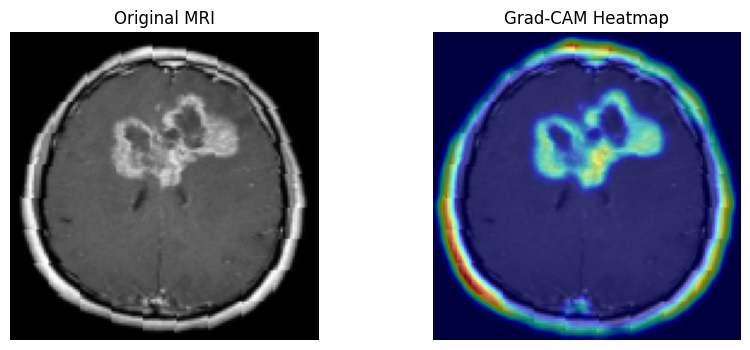

In [114]:
# take one image
images, labels = next(iter(test_loader))
image = images[0].unsqueeze(0)

cam = generate_gradcam(model, image, model.conv2)

# original image
img = image.squeeze().numpy()

plt.figure(figsize=(10,4))

# original
plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title("Original MRI")
plt.axis('off')

# heatmap
plt.subplot(1,2,2)
plt.imshow(img, cmap='gray')
plt.imshow(cam, cmap='jet', alpha=0.5)
plt.title("Grad-CAM Heatmap")
plt.axis('off')

plt.show()